# 线性回归基线实验 (Linear Regression Baseline)

**配置**: PV + NWP 天气预报 + 时间编码，24h lookback → 预测未来 24h (144 个 10min 步)

**运行方式**: 从上到下，依次执行每个 cell（每次 kernel 重启后需重新从头跑）

## Step 0：环境设置（挂载 Drive + 安装依赖）

In [ ]:
# 挂载 Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os, sys, time

# ⚠️ 如果项目不在 MyDrive/SolarPrediction，请修改这里
PROJECT_DIR = '/content/drive/MyDrive/SolarPrediction'

os.chdir(PROJECT_DIR)
sys.path.insert(0, PROJECT_DIR)

# 验证路径
assert os.path.exists(PROJECT_DIR), f'❌ 路径不存在: {PROJECT_DIR}'
assert os.path.exists(os.path.join(PROJECT_DIR, 'data', 'Project1033.csv')), '❌ 找不到数据文件'
print(f'✅ 项目路径: {PROJECT_DIR}')
print(f'✅ 数据文件: data/Project1033.csv  (正常场站，CF峰值13:00，无clipping)')

In [ ]:
# 安装依赖
!pip install -q xgboost lightgbm rich

## Step 1：加载数据

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

# ── 数据源：Project1033（正常场站，无clipping）──────────────
data_path = os.path.join(PROJECT_DIR, 'data', 'Project1033.csv')

t0 = time.time()
df_raw = pd.read_csv(data_path)
df_raw['Datetime'] = pd.to_datetime(df_raw['date'])

# ── Filter 1: 仅保留2022+（pred列只有2022年后有数据）──────────
before = len(df_raw)
df_raw = df_raw[df_raw['Datetime'].dt.year >= 2022].reset_index(drop=True)
print(f'Filter 1 (2022+): {before:,} → {len(df_raw):,} 行')

# ── Filter 2: 去除夜间irradiance异常（2024-09-27凌晨17行）────
night_anom = (df_raw['Datetime'].dt.hour < 5) & \
             (df_raw['global_tilted_irradiance_pred'].fillna(0) > 5)
df_raw = df_raw[~night_anom].reset_index(drop=True)
print(f'Filter 2 (夜间异常): 去除 {night_anom.sum()} 行')

print(f'\n数据大小  : {df_raw.shape[0]:,} 行 × {df_raw.shape[1]} 列')
print(f'时间范围  : {df_raw["Datetime"].min()} → {df_raw["Datetime"].max()}')
print(f'时间间隔  : 10 分钟（每小时 6 步，每天 144 步）')
print(f'加载耗时  : {time.time()-t0:.1f} 秒')
df_raw[['date', 'Capacity Factor', 'global_tilted_irradiance']].head()

## Step 2：实验配置

In [ ]:
config = {
    'model': 'Linear',
    'model_complexity': 'high',

    # 特征选择
    'use_pv': True,            # 历史发电量（PV）
    'use_hist_weather': False, # 历史天气（关闭）
    'use_forecast': True,      # NWP 天气预报（开启）
    'use_ideal_nwp': False,    # 理想天气（关闭，不作弊）
    'use_time_encoding': True, # 时间编码（开启）

    'weather_category': 'all_weather',
    'past_hours': 24,          # 回看 24h = 144 个 10min 步
    'future_hours': 24,        # 预测 24h = 144 个 10min 步
    'start_date': '2022-01-01',
    'end_date': '2024-09-28',
}

FUTURE_STEPS = config['future_hours'] * 6  # = 144
PAST_STEPS   = config['past_hours']   * 6  # = 144

print('实验配置:')
print(f'  模型        : Linear Regression（sklearn）')
print(f'  特征        : PV 历史发电 + NWP 天气预报 + 时间编码')
print(f'  回看窗口    : {config["past_hours"]}h = {PAST_STEPS} 步（10min/步）')
print(f'  预测窗口    : {config["future_hours"]}h = {FUTURE_STEPS} 步（10min/步）')
print(f'  训练数据    : {config["start_date"]} → {config["end_date"]}')

实验配置:
  模型        : Linear Regression（sklearn）
  特征        : PV 历史发电 + NWP 天气预报 + 时间编码
  回看窗口    : 24h = 144 步（10min/步）
  预测窗口    : 24h = 144 步（10min/步）
  训练数据    : 2022-01-01 → 2024-09-28


## Step 3：特征工程 + 滑动窗口

这一步会：
- 筛选日期范围，清洗数据
- 添加时间编码（sin/cos）
- 把时序数据切成「输入窗口 → 预测窗口」的样本对（滑动窗口）

In [ ]:
import gc
from data.data_utils import preprocess_features, create_sliding_windows

t0 = time.time()

# 特征预处理
df_clean, hist_feats, fcst_feats, scaler_hist, scaler_fcst, scaler_target, no_hist_power = \
    preprocess_features(df_raw.copy(), config)

# df_raw 用完即释放
del df_raw
gc.collect()
print('✅ df_raw 已释放')

# 创建滑动窗口
Xh, Xf, y, hours, dates = create_sliding_windows(
    df_clean, config['past_hours'], config['future_hours'],
    hist_feats, fcst_feats, no_hist_power
)

# df_clean 用完即释放
del df_clean
gc.collect()
print('✅ df_clean 已释放')

# float64 → float32，内存减半
Xh = Xh.astype(np.float32)
Xf = Xf.astype(np.float32) if Xf is not None else None
y  = y.astype(np.float32)
gc.collect()

print(f'\n滑动窗口结果:')
print(f'  历史输入 Xh : {Xh.shape}  dtype={Xh.dtype}')
print(f'  预报输入 Xf : {Xf.shape if Xf is not None else "None"}')
print(f'  预测目标 y  : {y.shape}')
print(f'耗时: {time.time()-t0:.1f} 秒')

# 当前内存使用
import psutil
ram = psutil.virtual_memory()
print(f'\n内存使用: {ram.used/1e9:.1f} GB / {ram.total/1e9:.1f} GB  ({ram.percent:.0f}%)')

✅ df_raw 已释放


✅ df_clean 已释放

滑动窗口结果:
  历史输入 Xh : (143858, 144, 9)  dtype=float32
  预报输入 Xf : (143858, 144, 15)
  预测目标 y  : (143858, 144)
耗时: 314.8 秒

内存使用: 18.9 GB / 54.8 GB  (44%)


## Step 4：划分训练/测试集

按时间顺序切分（**不能随机打乱**，时间序列必须保证时序不泄露）

In [ ]:
total     = len(Xh)
train_end = int(total * 0.85)

Xh_train, Xh_test = Xh[:train_end], Xh[train_end:]
Xf_train = Xf[:train_end] if Xf is not None else None
Xf_test  = Xf[train_end:] if Xf is not None else None
y_train,  y_test  = y[:train_end],  y[train_end:]
dates_test = dates[train_end:]

print(f'总样本    : {total:,}')
print(f'训练集    : {train_end:,}  ({train_end/total*100:.0f}%)')
print(f'测试集    : {total-train_end:,}  ({(total-train_end)/total*100:.0f}%)')
print(f'\n每个样本:')
print(f'  输入  : 过去 {PAST_STEPS} 步（{config["past_hours"]}h）的特征')
print(f'  输出  : 未来 {FUTURE_STEPS} 步（{config["future_hours"]}h）的发电量')

总样本    : 143,858
训练集    : 122,279  (85%)
测试集    : 21,579  (15%)

每个样本:
  输入  : 过去 144 步（24h）的特征
  输出  : 未来 144 步（24h）的发电量


In [ ]:
# 保存处理好的数据，供其他模型（XGBoost 等）直接加载，避免重复特征工程
import pickle

cache_path = os.path.join(PROJECT_DIR, 'data_cache.pkl')
cache = {
    'Xh': Xh, 'Xf': Xf, 'y': y,
    'dates': dates,
    'scaler_target': scaler_target,
    'config': config,
    'train_end': train_end,
}
with open(cache_path, 'wb') as f:
    pickle.dump(cache, f)

print(f'✅ 数据已缓存到: {cache_path}')
print(f'   Xh: {Xh.shape}, Xf: {Xf.shape}, y: {y.shape}')

✅ 数据已缓存到: /content/drive/MyDrive/SolarPrediction/data_cache.pkl
   Xh: (143858, 144, 9), Xf: (143858, 144, 15), y: (143858, 144)


In [ ]:
import models.ml_models as ml_mod
ml_mod.GPU_AVAILABLE = False
print("✅ 已切换为 sklearn CPU LinearRegression")


✅ 已切换为 sklearn CPU LinearRegression


## Step 5：训练 Linear Regression 并计时

线性回归本质是求解一个最小二乘问题（OLS），无需迭代，一次性求解——**预计几秒到几十秒完成**。

In [ ]:
from train.train_ml import train_ml_model

# cuML GPU 版 LinearRegression 显存需求极大（>10GB），强制使用 CPU sklearn 版
import models.ml_models as ml_mod
ml_mod.GPU_AVAILABLE = False
print("✅ 已强制使用 sklearn CPU LinearRegression（cuML 显存不足）")

print(f'\n开始训练 Linear Regression...')
print(f'训练样本数  : {len(Xh_train):,}')
print(f'输入特征维度: {Xh_train.reshape(len(Xh_train), -1).shape[1] + (Xf_train.reshape(len(Xf_train), -1).shape[1] if Xf_train is not None else 0)}')
print(f'输出维度    : {FUTURE_STEPS} 步（同时预测 144 个 10min 步）')
print()

t_start = time.time()
linear_model, linear_metrics = train_ml_model(
    config,
    Xh_train, Xf_train, y_train,
    Xh_test,  Xf_test,  y_test,
    dates_test,
    scaler_target=scaler_target
)
train_time = time.time() - t_start

print(f'\n✅ 训练完成！')
print(f'   实际训练时间: {train_time:.1f} 秒')
if train_time < 10:
    print(f'   （非常快，线性回归无需迭代，直接矩阵求解）')
elif train_time < 60:
    print(f'   （正常范围：特征维度较高时 OLS 需要更多时间）')
else:
    print(f'   （数据量较大，属正常）')

✅ 已强制使用 sklearn CPU LinearRegression（cuML 显存不足）

开始训练 Linear Regression...
训练样本数  : 122,279
输入特征维度: 3456
输出维度    : 144 步（同时预测 144 个 10min 步）



Training Linear:   0%|          | 0/10 [02:52<?, ?it/s]



✅ 训练完成！
   实际训练时间: 176.1 秒
   （数据量较大，属正常）


## Step 6：评估指标（预测 vs 实际）

In [ ]:
m = linear_metrics

print('=' * 50)
print('Linear Regression 基线结果')
print('=' * 50)
print(f'\n【整体指标（全天 24h）】')
print(f'  MAE   = {m["mae"]:.4f}   ← 平均绝对误差（容量因子单位）')
print(f'  RMSE  = {m["rmse"]:.4f}   ← 均方根误差')
print(f'  R²    = {m["r2"]:.4f}   ← 决定系数（越接近1越好）')
print(f'  sMAPE = {m["smape"]:.2f}%    ← 对称平均绝对百分比误差')

print(f'\n【白天指标（10am–6pm，发电高峰）】')
print(f'  MAE   = {m["daytime_mae"]:.4f}')
print(f'  RMSE  = {m["daytime_rmse"]:.4f}')
print(f'  R²    = {m["daytime_r2"]:.4f}')
print(f'  sMAPE = {m["daytime_smape"]:.2f}%')

print(f'\n【数据统计】')
print(f'  测试样本数  : {m["samples_count"]:,}')
print(f'  训练时间    : {train_time:.1f} 秒')

Linear Regression 基线结果

【整体指标（全天 24h）】
  MAE   = 3.1985   ← 平均绝对误差（容量因子单位）
  RMSE  = 5.5321   ← 均方根误差
  R²    = 0.9421   ← 决定系数（越接近1越好）
  sMAPE = 0.78%    ← 对称平均绝对百分比误差

【白天指标（10am–6pm，发电高峰）】
  MAE   = 3.2717
  RMSE  = 5.5936
  R²    = 0.9408
  sMAPE = 0.79%

【数据统计】
  测试样本数  : 21,579
  训练时间    : 176.1 秒


## Step 7：可视化（一）时序预测对比图

随机选取 6 天的预测结果，对比预测值 vs 实际值

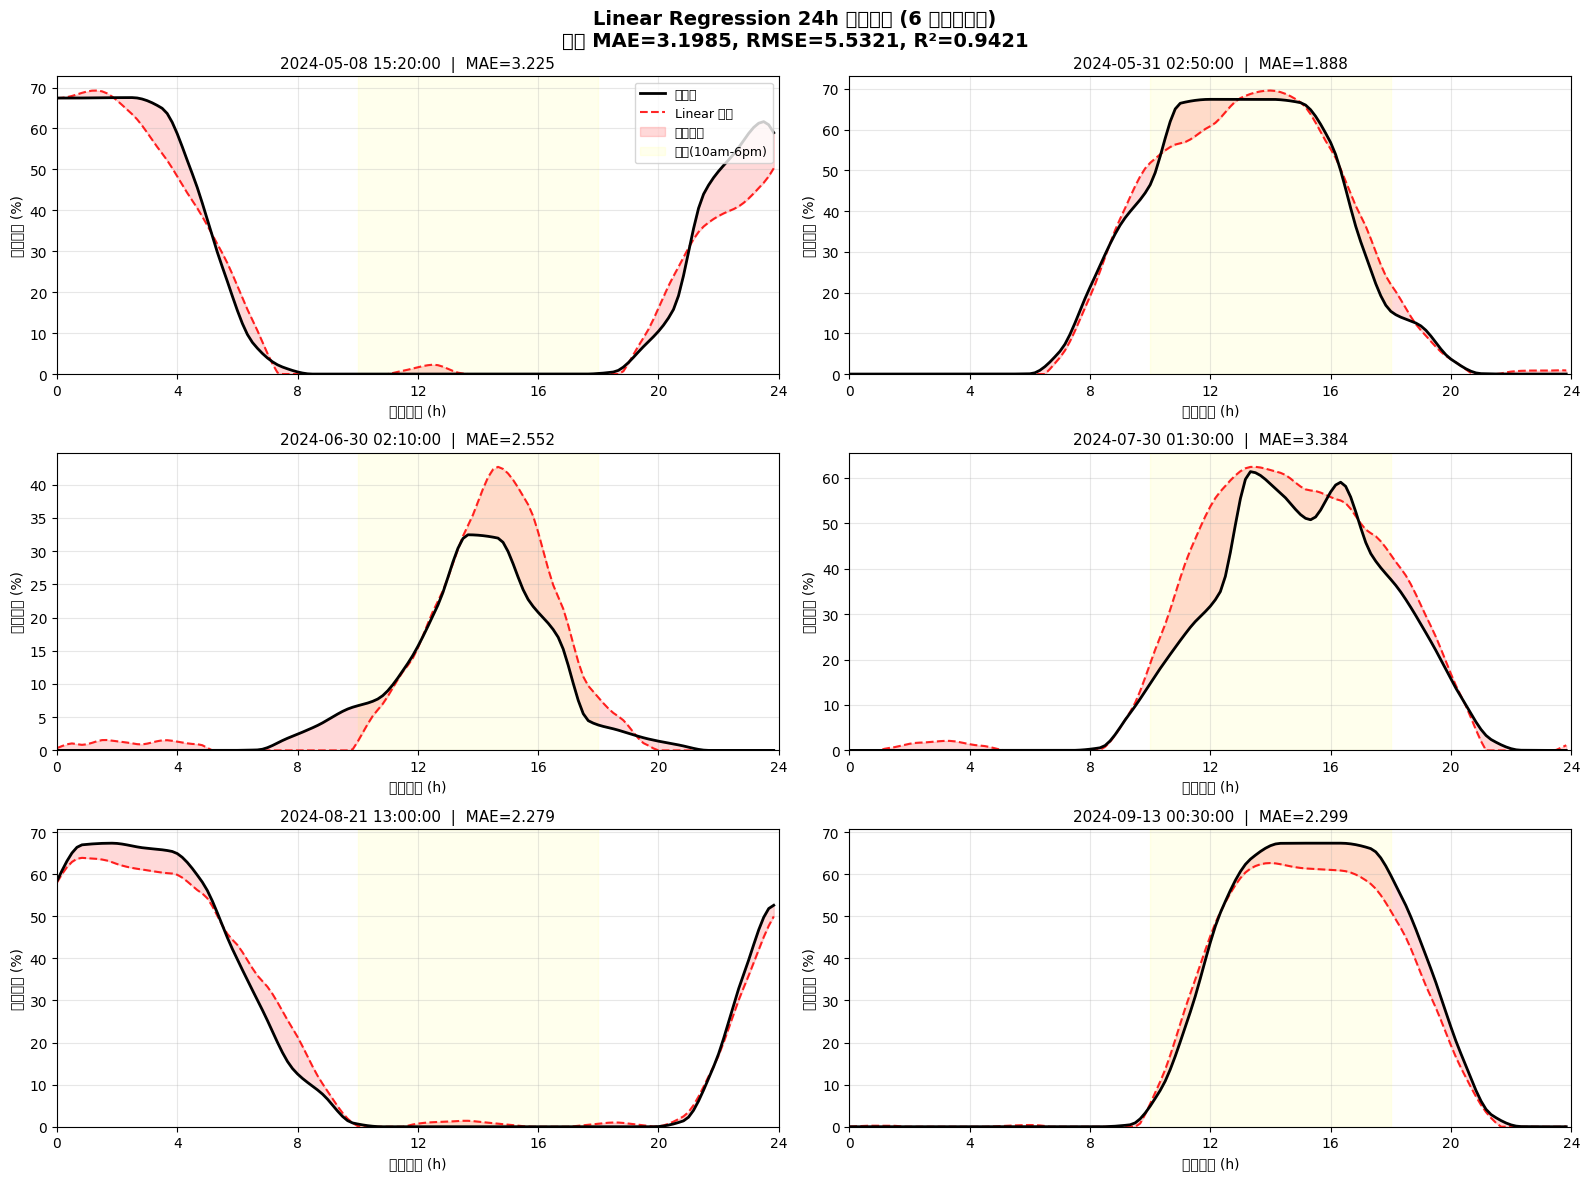

图片已保存: /content/drive/MyDrive/SolarPrediction/linear_timeseries.png


In [ ]:
y_true  = m['y_true']       # shape: (n_test, 144)
y_pred  = m['predictions']  # shape: (n_test, 144)
t_axis  = np.arange(FUTURE_STEPS) * 10 / 60  # 转换为小时（0~24h）

# 挑选 6 个时间均匀分布的测试样本
n_test  = len(y_true)
sample_indices = [int(n_test * r) for r in [0.05, 0.2, 0.4, 0.6, 0.75, 0.9]]

fig, axes = plt.subplots(3, 2, figsize=(16, 12))
axes = axes.flatten()

for plot_i, idx in enumerate(sample_indices):
    ax = axes[plot_i]
    ax.plot(t_axis, y_true[idx], 'k-',  linewidth=2,   label='实际值', zorder=3)
    ax.plot(t_axis, y_pred[idx], 'r--', linewidth=1.5, label='Linear 预测', alpha=0.85, zorder=2)
    ax.fill_between(t_axis, y_true[idx], y_pred[idx],
                    alpha=0.15, color='red', label='误差区域')

    # 标注白天区域（10am-6pm）
    ax.axvspan(10, 18, alpha=0.07, color='yellow', label='白天(10am-6pm)')

    # 计算该样本的 MAE
    sample_mae = np.mean(np.abs(y_true[idx] - y_pred[idx]))
    date_label = dates_test[idx] if idx < len(dates_test) else f'样本 {idx}'
    ax.set_title(f'{date_label}  |  MAE={sample_mae:.3f}', fontsize=11)
    ax.set_xlabel('预测时间 (h)')
    ax.set_ylabel('容量因子 (%)')
    ax.set_xlim(0, 24)
    ax.set_xticks(range(0, 25, 4))
    ax.set_ylim(bottom=0)
    ax.grid(True, alpha=0.3)
    if plot_i == 0:
        ax.legend(loc='upper right', fontsize=9)

plt.suptitle(f'Linear Regression 24h 预测对比 (6 个测试样本)\n'
             f'整体 MAE={m["mae"]:.4f}, RMSE={m["rmse"]:.4f}, R²={m["r2"]:.4f}',
             fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(PROJECT_DIR, 'linear_timeseries.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'图片已保存: {save_path}')

## Step 8：可视化（二）散点图 — 预测值 vs 实际值

理想情况下所有点应落在对角线（y=x）上

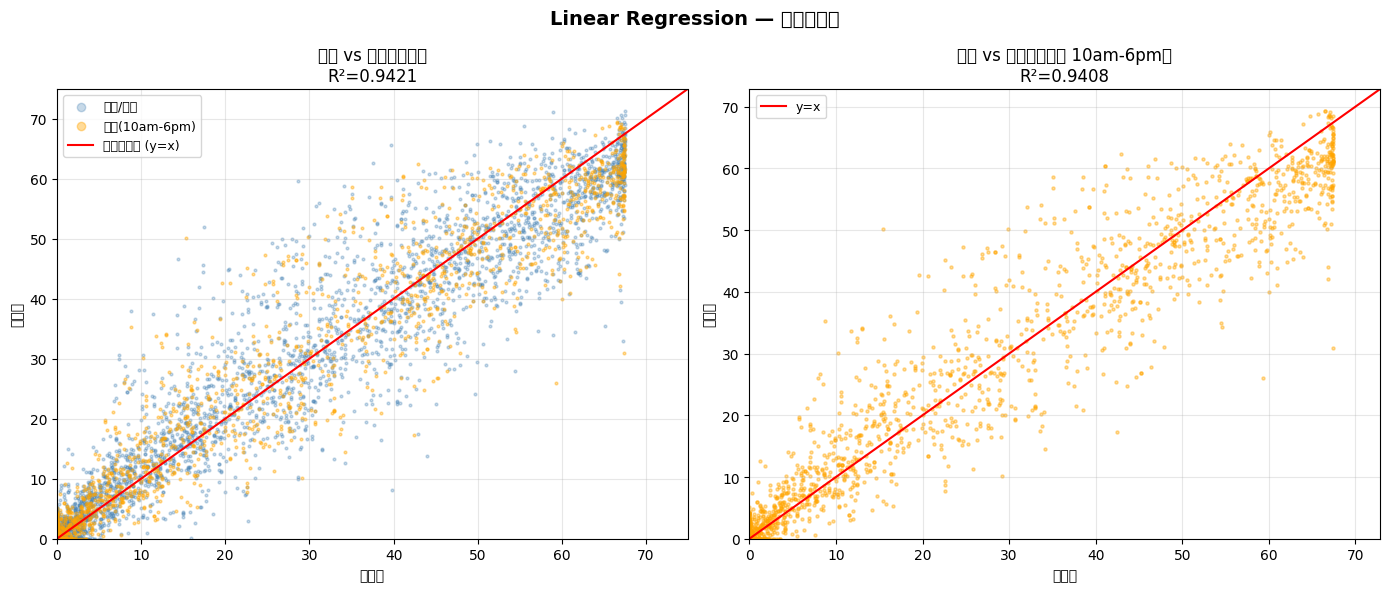

图片已保存: /content/drive/MyDrive/SolarPrediction/linear_scatter.png


In [ ]:
# 为了散点图不太密，随机采样 5000 个点
flat_true = y_true.flatten()
flat_pred = y_pred.flatten()

np.random.seed(42)
sample_n = min(8000, len(flat_true))
idx_sample = np.random.choice(len(flat_true), sample_n, replace=False)
st = flat_true[idx_sample]
sp = flat_pred[idx_sample]

# 区分白天（slot 60-107）和夜晚
step_in_day = np.tile(np.arange(FUTURE_STEPS), len(y_true)).flatten()
is_daytime  = ((step_in_day >= 60) & (step_in_day < 108)).flatten()  # 10am-6pm
is_day_sample = is_daytime[idx_sample]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：全天散点
ax = axes[0]
ax.scatter(st[~is_day_sample], sp[~is_day_sample],
           alpha=0.3, s=4, c='steelblue', label='夜间/清晨')
ax.scatter(st[is_day_sample], sp[is_day_sample],
           alpha=0.4, s=4, c='orange', label='白天(10am-6pm)')
lim = max(st.max(), sp.max()) * 1.05
ax.plot([0, lim], [0, lim], 'r-', linewidth=1.5, label='理想预测线 (y=x)')
ax.set_xlabel('实际值')
ax.set_ylabel('预测值')
ax.set_title(f'预测 vs 实际（全天）\nR²={m["r2"]:.4f}')
ax.legend(markerscale=3, fontsize=9)
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.grid(True, alpha=0.3)

# 右图：仅白天
ax2 = axes[1]
st_day = flat_true[idx_sample][is_day_sample]
sp_day = flat_pred[idx_sample][is_day_sample]
ax2.scatter(st_day, sp_day, alpha=0.4, s=5, c='orange')
lim2 = max(st_day.max(), sp_day.max()) * 1.05
ax2.plot([0, lim2], [0, lim2], 'r-', linewidth=1.5, label='y=x')
ax2.set_xlabel('实际值')
ax2.set_ylabel('预测值')
ax2.set_title(f'预测 vs 实际（仅白天 10am-6pm）\nR²={m["daytime_r2"]:.4f}')
ax2.legend(fontsize=9)
ax2.set_xlim(0, lim2); ax2.set_ylim(0, lim2)
ax2.grid(True, alpha=0.3)

plt.suptitle('Linear Regression — 散点图分析', fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(PROJECT_DIR, 'linear_scatter.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'图片已保存: {save_path}')

## Step 9：可视化（三）误差分布直方图

误差统计:
  均值   = 0.0193  （接近0说明无系统性偏差）
  标准差 = 5.5320
  最大   = 38.4691
  最小   = -42.7658
  误差最大时刻 = 2.7h  (MAE=3.5657)


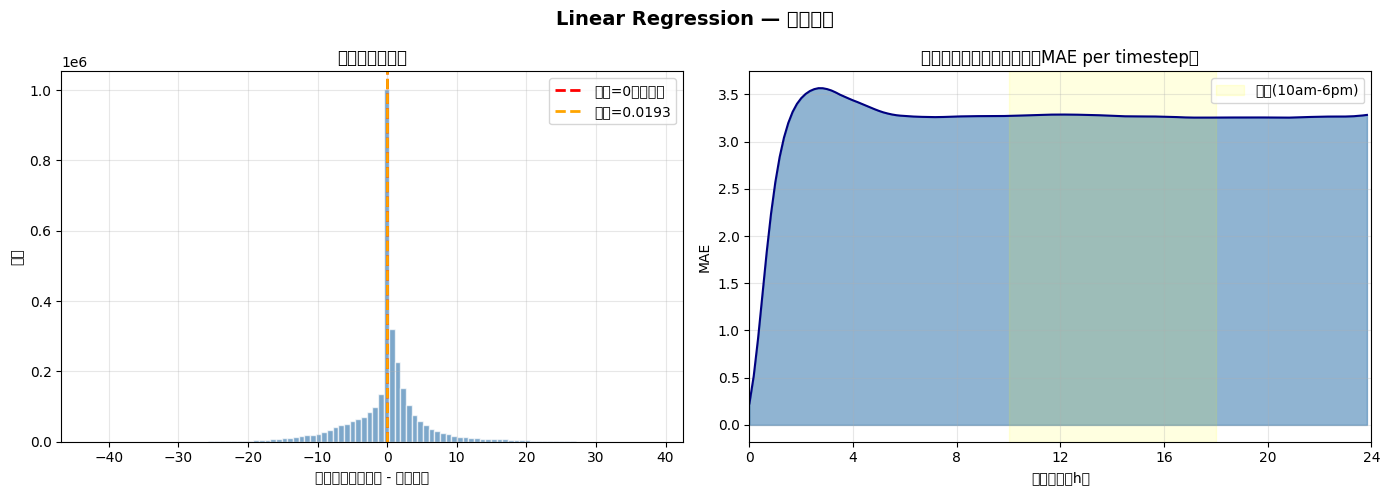

图片已保存: /content/drive/MyDrive/SolarPrediction/linear_error.png


In [ ]:
errors = (y_pred - y_true).flatten()  # 所有预测误差

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：误差直方图
ax = axes[0]
ax.hist(errors, bins=100, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(0,              color='red',    linewidth=2, linestyle='--', label='误差=0（理想）')
ax.axvline(errors.mean(),  color='orange', linewidth=2, linestyle='--',
           label=f'均值={errors.mean():.4f}')
ax.set_xlabel('预测误差（预测值 - 实际值）')
ax.set_ylabel('频次')
ax.set_title('误差分布直方图')
ax.legend()
ax.grid(True, alpha=0.3)

# 右图：按时刻的平均绝对误差（每天 144 步）
ax2 = axes[1]
mae_per_step = np.mean(np.abs(y_pred - y_true), axis=0)  # shape (144,)
t_axis_full  = np.arange(FUTURE_STEPS) * 10 / 60

ax2.fill_between(t_axis_full, mae_per_step, alpha=0.6, color='steelblue')
ax2.plot(t_axis_full, mae_per_step, color='navy', linewidth=1.5)
ax2.axvspan(10, 18, alpha=0.12, color='yellow', label='白天(10am-6pm)')
ax2.set_xlabel('预测时刻（h）')
ax2.set_ylabel('MAE')
ax2.set_title('每个时刻的平均绝对误差（MAE per timestep）')
ax2.set_xlim(0, 24)
ax2.set_xticks(range(0, 25, 4))
ax2.legend()
ax2.grid(True, alpha=0.3)

# 统计
print(f'误差统计:')
print(f'  均值   = {errors.mean():.4f}  （接近0说明无系统性偏差）')
print(f'  标准差 = {errors.std():.4f}')
print(f'  最大   = {errors.max():.4f}')
print(f'  最小   = {errors.min():.4f}')
peak_step = np.argmax(mae_per_step)
print(f'  误差最大时刻 = {t_axis_full[peak_step]:.1f}h  (MAE={mae_per_step[peak_step]:.4f})')

plt.suptitle('Linear Regression — 误差分析', fontsize=14, fontweight='bold')
plt.tight_layout()

save_path = os.path.join(PROJECT_DIR, 'linear_error.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'图片已保存: {save_path}')

## Step 10：训练时间分析

In [ ]:
# 输入维度
Xh_flat = Xh_train.reshape(len(Xh_train), -1)
Xf_flat = Xf_train.reshape(len(Xf_train), -1) if Xf_train is not None else np.zeros((len(Xh_train), 0))
total_input_dim = Xh_flat.shape[1] + Xf_flat.shape[1]

print('=' * 55)
print('训练时间分析')
print('=' * 55)
print(f'\n训练数据规模:')
print(f'  样本数         : {len(Xh_train):,}')
print(f'  输入维度       : {total_input_dim}  （展平后）')
print(f'  输出维度       : {FUTURE_STEPS}  （同时预测 144 步）')

print(f'\n训练时间:')
print(f'  实际耗时       : {train_time:.2f} 秒')
print(f'  原因解释       : Linear Regression 是解析解（OLS），')
print(f'                   无需迭代，直接矩阵运算，所以非常快。')
print(f'  对比参考       :')
print(f'     XGBoost     ≈ 2~10 分钟（需要迭代构建 800 棵树）')
print(f'     LSTM/TCN    ≈ 30~120 分钟（深度学习，多个 epoch）')

print(f'\n结果汇总:')
print(f'  MAE   = {m["mae"]:.4f}')
print(f'  RMSE  = {m["rmse"]:.4f}')
print(f'  R²    = {m["r2"]:.4f}')
print(f'  sMAPE = {m["smape"]:.2f}%')

训练时间分析

训练数据规模:
  样本数         : 122,279
  输入维度       : 3456  （展平后）
  输出维度       : 144  （同时预测 144 步）

训练时间:
  实际耗时       : 176.05 秒
  原因解释       : Linear Regression 是解析解（OLS），
                   无需迭代，直接矩阵运算，所以非常快。
  对比参考       :
     XGBoost     ≈ 2~10 分钟（需要迭代构建 800 棵树）
     LSTM/TCN    ≈ 30~120 分钟（深度学习，多个 epoch）

结果汇总:
  MAE   = 3.1985
  RMSE  = 5.5321
  R²    = 0.9421
  sMAPE = 0.78%


## 实验完成 ✅

**已生成图表（保存到 Drive）：**
- `linear_timeseries.png` — 6 个样本的时序预测对比
- `linear_scatter.png` — 散点图（预测 vs 实际）
- `linear_error.png` — 误差分布 + 每时刻 MAE

**下一步建议：**
- 跑 XGBoost (`config['model'] = 'XGB'`) 对比提升多少
- 做消融实验：去掉 NWP（`use_forecast=False`）看影响
- 尝试 LSTM 或 TCN 看深度学习能否超越

## Step 11：导出预测对照表（预测值 vs 真实值，按时间对齐）

将所有测试集预测结果与真实值按时间戳一一对应，保存为 CSV 供后续分析。

In [35]:

# 保存为 CSV（完整版 + 精简版）

# ── 完整版：所有窗口 × 所有时间步（约 310 万行）──────────────
csv_full = os.path.join(PROJECT_DIR, 'linear_predictions_full.csv')
df_pred.to_csv(csv_full, index=False)
print(f'✅ 完整对照表已保存: {csv_full}')
print(f'   行数: {len(df_pred):,}   大小: ~{len(df_pred)*8*8/1e6:.0f} MB')

# ── 精简版：每个唯一时间戳只保留 window_id 最新的那一次预测 ──
# （窗口有重叠，同一 forecast_datetime 可能来自不同窗口，取最新窗口的预测）
df_latest = (
    df_pred
    .sort_values(['forecast_datetime', 'window_id'])
    .drop_duplicates(subset='forecast_datetime', keep='last')
    .sort_values('forecast_datetime')
    .reset_index(drop=True)
)

csv_slim = os.path.join(PROJECT_DIR, 'linear_predictions_slim.csv')
df_latest[['forecast_datetime', 'actual', 'predicted', 'error', 'is_daytime']].to_csv(csv_slim, index=False)
print(f'\n✅ 精简对照表已保存: {csv_slim}')
print(f'   行数: {len(df_latest):,}  （每个时间戳一行，去重后）')
print(f'\n精简版前 10 行:')
print(df_latest[['forecast_datetime', 'actual', 'predicted', 'error']].head(10).to_string(index=False))


✅ 完整对照表已保存: /content/drive/MyDrive/SolarPrediction/linear_predictions_full.csv
   行数: 3,107,376   大小: ~199 MB

✅ 精简对照表已保存: /content/drive/MyDrive/SolarPrediction/linear_predictions_slim.csv
   行数: 21,722  （每个时间戳一行，去重后）

精简版前 10 行:
  forecast_datetime  actual  predicted    error
2024-04-30 03:50:00     0.0   0.000000 0.000000
2024-04-30 04:00:00     0.0   0.000000 0.000000
2024-04-30 04:10:00     0.0   0.000000 0.000000
2024-04-30 04:20:00     0.0   0.341562 0.341562
2024-04-30 04:30:00     0.0   0.000000 0.000000
2024-04-30 04:40:00     0.0   0.000000 0.000000
2024-04-30 04:50:00     0.0   0.000000 0.000000
2024-04-30 05:00:00     0.0   0.000000 0.000000
2024-04-30 05:10:00     0.0   0.158297 0.158297
2024-04-30 05:20:00     0.0   0.247159 0.247159


In [34]:
# Step 11: 导出预测对照表
# dates_test[i] 是第 i 个预测窗口的最后一个时刻（窗口末尾）
# 144 个时间步 = 窗口末尾往前推 143×10min 到末尾

import pandas as pd
import numpy as np

y_true_arr = m['y_true']       # shape: (n_test, 144)
y_pred_arr = m['predictions']  # shape: (n_test, 144)
n_test, STEPS = y_true_arr.shape  # 21579, 144

print(f'构建预测对照表...')
print(f'  测试窗口数   : {n_test:,}')
print(f'  每窗口时间步 : {STEPS}  (10min/步)')
print(f'  总数据点     : {n_test * STEPS:,}')

# ── 向量化构建 forecast_datetime ──────────────────────────────
# 转成 numpy datetime64 数组才能广播
window_ends_ns = pd.to_datetime(dates_test).values.astype('datetime64[ns]')  # (n_test,) numpy

# offsets[j] = -(143-j)*10min，使得 j=0 → -1430min，j=143 → 0
offsets_ns = ((np.arange(STEPS) - (STEPS - 1)) * 10 * 60 * 1_000_000_000).astype('timedelta64[ns]')  # (144,)

# 广播：(n_test, 1) + (1, 144) → (n_test, 144)
forecast_datetimes = window_ends_ns[:, np.newaxis] + offsets_ns[np.newaxis, :]  # (n_test, 144)

# ── 展平并组装 DataFrame ──────────────────────────────────────
window_start_ns = window_ends_ns - np.timedelta64(int((STEPS - 1) * 10 * 60 * 1e9), 'ns')

df_pred = pd.DataFrame({
    'window_id':         np.repeat(np.arange(n_test), STEPS),
    'window_start':      np.repeat(window_start_ns, STEPS),
    'forecast_datetime': forecast_datetimes.flatten(),
    'timestep':          np.tile(np.arange(STEPS), n_test),
    'actual':            y_true_arr.flatten().astype(float),
    'predicted':         y_pred_arr.flatten().astype(float),
    'error':             (y_pred_arr - y_true_arr).flatten().astype(float),
})

# 判断是否白天（10am–6pm 对应 step 60–107）
df_pred['is_daytime'] = (df_pred['timestep'] >= 60) & (df_pred['timestep'] < 108)

print(f'\n✅ 对照表构建完成')
print(df_pred.head(10).to_string(index=False))
print(f'\n列说明:')
print(f'  window_id        : 测试窗口编号（0 ~ {n_test-1}）')
print(f'  window_start     : 预测窗口起始时间')
print(f'  forecast_datetime: 该行对应的实际时间戳（与原始数据对齐）')
print(f'  timestep         : 窗口内时间步编号（0=窗口第1步，143=最后一步）')
print(f'  actual           : 真实容量因子（%，反归一化后）')
print(f'  predicted        : 线性回归预测值（%）')
print(f'  error            : 误差 = predicted - actual')
print(f'  is_daytime       : 是否为白天（10am–6pm）')

构建预测对照表...
  测试窗口数   : 21,579
  每窗口时间步 : 144  (10min/步)
  总数据点     : 3,107,376

✅ 对照表构建完成
 window_id        window_start   forecast_datetime  timestep  actual  predicted  error  is_daytime
         0 2024-04-30 03:50:00 2024-04-30 03:50:00         0     0.0        0.0    0.0       False
         0 2024-04-30 03:50:00 2024-04-30 04:00:00         1     0.0        0.0    0.0       False
         0 2024-04-30 03:50:00 2024-04-30 04:10:00         2     0.0        0.0    0.0       False
         0 2024-04-30 03:50:00 2024-04-30 04:20:00         3     0.0        0.0    0.0       False
         0 2024-04-30 03:50:00 2024-04-30 04:30:00         4     0.0        0.0    0.0       False
         0 2024-04-30 03:50:00 2024-04-30 04:40:00         5     0.0        0.0    0.0       False
         0 2024-04-30 03:50:00 2024-04-30 04:50:00         6     0.0        0.0    0.0       False
         0 2024-04-30 03:50:00 2024-04-30 05:00:00         7     0.0        0.0    0.0       False
         0 2024-04-